# 04 - Linear function modeling of swim performance


# Common setup

These notebooks assume a local project structure like:

```text
project/
  data/
    workouts.csv
    samples.csv              # optional
    intervals.csv            # optional
    race_results.csv          # optional
```

The exact iOS export format may vary. The helper functions below try to standardize common column names. If your export uses different names, edit the `COLUMN_ALIASES` dictionary.

The notebooks also include a small synthetic-data fallback. That lets the notebook run even before real Apple Watch / iOS CSV files are placed in `data/`.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [1]:
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

clean_path = PROCESSED_DIR / "clean_workouts.csv"
weekly_path = PROCESSED_DIR / "weekly_training.csv"

if not clean_path.exists() or not weekly_path.exists():
    raise FileNotFoundError("Run 01_swim_data_ingestion_and_cleaning.ipynb first to create prepared swim data.")

workouts = pd.read_csv(clean_path)
weekly = pd.read_csv(weekly_path)

workouts["date"] = pd.to_datetime(workouts["date"], errors="coerce", utc=True).dt.tz_convert(None)
if "week_start" in workouts.columns:
    workouts["week_start"] = pd.to_datetime(workouts["week_start"], errors="coerce", utc=True).dt.tz_convert(None)
else:
    workouts["week_start"] = workouts["date"].dt.to_period("W").dt.start_time

weekly["week_start"] = pd.to_datetime(weekly["week_start"], errors="coerce", utc=True).dt.tz_convert(None)
weekly = weekly.dropna(subset=["week_start", "avg_pace_sec_per_100m"]).sort_values("week_start").reset_index(drop=True)
weekly["week_index"] = (weekly["week_start"] - weekly["week_start"].min()).dt.days / 7
weekly["cumulative_distance_m"] = weekly["total_distance_m"].fillna(0).cumsum()

workouts = workouts.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
workouts["season_half"] = np.where(workouts["date"] < workouts["date"].median(), "First half", "Second half")

print("Loaded prepared workouts:", len(workouts))
print("Loaded prepared weekly rows:", len(weekly))
display(weekly.head(3))
display(weekly.tail(3))


Loaded prepared workouts: 452
Loaded prepared weekly rows: 104


,week_start,sessions,total_distance_m,avg_distance_m,avg_pace_sec_per_100m,median_pace_sec_per_100m,avg_hr,avg_distance_per_stroke_m,avg_swolf,week_index,cumulative_distance_m
0,2024-05-27,2,4686.300125,2343.150063,140.445602,140.445602,NaN,2.296495,NaN,0.0,4686.300125
1,2024-06-03,4,11978.640320,2994.660080,94.599379,94.450755,NaN,2.881921,NaN,1.0,16664.940445
2,2024-06-10,6,22821.800079,3803.633347,115.768771,79.489092,NaN,2.696377,NaN,2.0,39486.740524


,week_start,sessions,total_distance_m,avg_distance_m,avg_pace_sec_per_100m,median_pace_sec_per_100m,avg_hr,avg_distance_per_stroke_m,avg_swolf,week_index,cumulative_distance_m
101,2026-06-01,8,23565.900345,2945.737543,136.489127,132.297215,NaN,2.647709,NaN,105.0,1.448233e+06
102,2026-06-08,4,14934.640076,3733.660019,116.752654,117.050274,NaN,2.977347,NaN,106.0,1.463168e+06
103,2026-06-15,4,15888.920074,3972.230019,118.164580,117.288954,NaN,2.922873,NaN,107.0,1.479057e+06


## Linear model

A linear model assumes a constant average change in pace each week:

$$
y = mx + b
$$

where `x` is weeks since the first recorded swim and `y` is average pace in seconds per 100 meters.

Code-style implementation:

```python
lin = LinearRegression().fit(X, y)
model_df["linear_pred"] = lin.predict(X)
```

Expanded as code-style math:

```python
linear_pred = lin.coef_[0] * week_index + lin.intercept_
```

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


Linear model: pace = 0.064 * week + 102.548
R²: 0.018
RMSE: 14.73 sec/100m


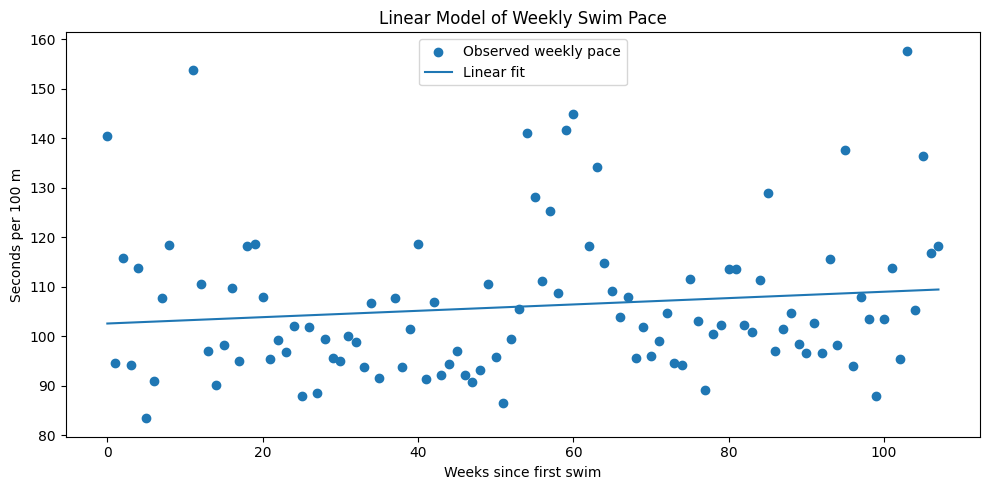

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

model_df = weekly.dropna(subset=["week_index", "avg_pace_sec_per_100m"]).copy()
X = model_df[["week_index"]].values
y = model_df["avg_pace_sec_per_100m"].values

lin = LinearRegression().fit(X, y)
model_df["linear_pred"] = lin.predict(X)

print(f"Linear model: pace = {lin.coef_[0]:.3f} * week + {lin.intercept_:.3f}")
print(f"R²: {r2_score(y, model_df['linear_pred']):.3f}")
print(f"RMSE: {math.sqrt(mean_squared_error(y, model_df['linear_pred'])):.2f} sec/100m")

plt.figure(figsize=(10, 5))
plt.scatter(model_df["week_index"], y, label="Observed weekly pace")
plt.plot(model_df["week_index"], model_df["linear_pred"], label="Linear fit")
plt.title("Linear Model of Weekly Swim Pace")
plt.xlabel("Weeks since first swim")
plt.ylabel("Seconds per 100 m")
plt.legend()
plt.tight_layout()
plt.show()

## Logarithmic model for diminishing returns

Athletic improvement often slows over time. A logarithmic model can represent large early gains followed by smaller later gains:

$$
y = a + b\ln(x + 1)
$$

The `+1` keeps the expression defined when `x = 0`.

Code-style implementation:

```python
log_df["log_week"] = np.log1p(log_df["week_index"])
log_model = LinearRegression().fit(log_df[["log_week"]], y)
log_df["log_pred"] = log_model.predict(log_df[["log_week"]])
```

**Expected output:** Expect model fit information such as slopes, predictions, errors, or residuals. Focus on both the trend and how much variation remains unexplained.


Log model: pace = 104.203 + 0.493 ln(week + 1)


R²: 0.001
RMSE: 14.86 sec/100m


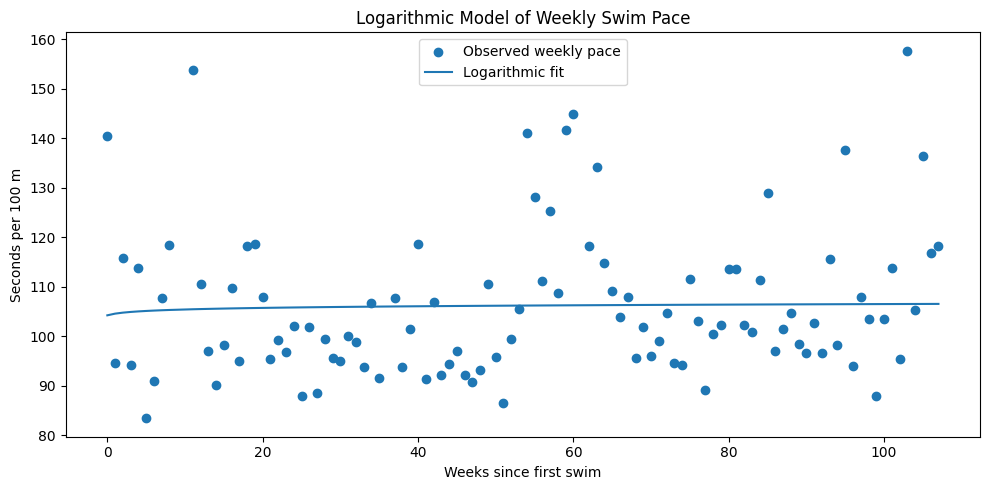

In [3]:
log_df = model_df.copy()
log_df["log_week"] = np.log1p(log_df["week_index"])

log_model = LinearRegression().fit(log_df[["log_week"]], y)
log_df["log_pred"] = log_model.predict(log_df[["log_week"]])

print(f"Log model: pace = {log_model.intercept_:.3f} + {log_model.coef_[0]:.3f} ln(week + 1)")
print(f"R²: {r2_score(y, log_df['log_pred']):.3f}")
print(f"RMSE: {math.sqrt(mean_squared_error(y, log_df['log_pred'])):.2f} sec/100m")

plt.figure(figsize=(10, 5))
plt.scatter(log_df["week_index"], y, label="Observed weekly pace")
plt.plot(log_df["week_index"], log_df["log_pred"], label="Logarithmic fit")
plt.title("Logarithmic Model of Weekly Swim Pace")
plt.xlabel("Weeks since first swim")
plt.ylabel("Seconds per 100 m")
plt.legend()
plt.tight_layout()
plt.show()

## Exponential-style transformation

Another model for diminishing improvement is an exponential approach toward a performance floor:

$$
y = C + Ae^{-kx}
$$

`C` is the estimated floor, or the pace the model approaches over time.

Code-style implementation:

```python
exp_df["log_above_floor"] = np.log(exp_df["avg_pace_sec_per_100m"] - C)
exp_model = LinearRegression().fit(exp_df[["week_index"]], exp_df["log_above_floor"])
exp_df["exp_pred"] = C + A * np.exp(-k * exp_df["week_index"])
```

**Expected output:** Expect model fit information such as slopes, predictions, errors, or residuals. Focus on both the trend and how much variation remains unexplained.


Estimated floor C: 80.38 sec/100m
Exponential-style model: pace = 80.38 + 18.32e^(--0.0034x)
R² on original scale: -0.038
RMSE: 15.14 sec/100m


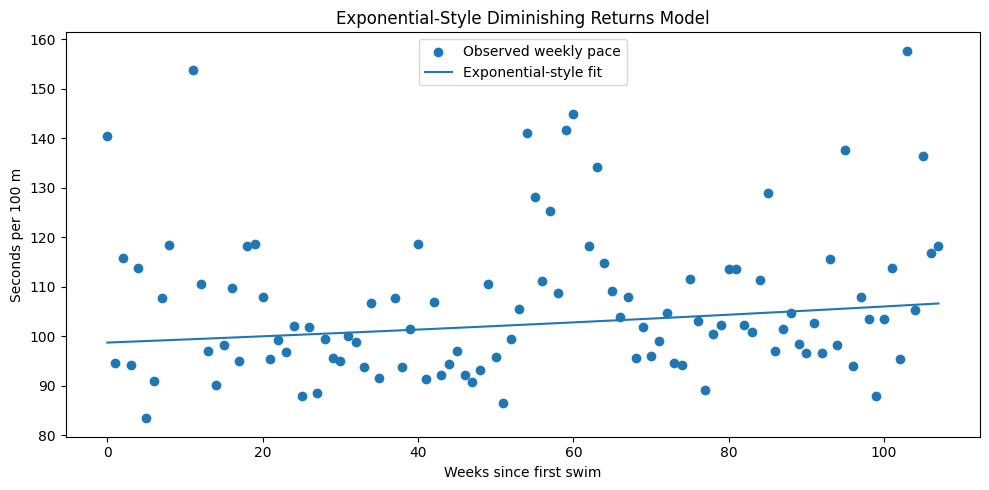

In [4]:
exp_df = model_df.copy()
C = max(1, exp_df["avg_pace_sec_per_100m"].min() - 3)
exp_df["above_floor"] = exp_df["avg_pace_sec_per_100m"] - C
exp_df = exp_df[exp_df["above_floor"] > 0].copy()
exp_df["log_above_floor"] = np.log(exp_df["above_floor"])

exp_model = LinearRegression().fit(exp_df[["week_index"]], exp_df["log_above_floor"])
A = math.exp(exp_model.intercept_)
k = -exp_model.coef_[0]
exp_df["exp_pred"] = C + A * np.exp(-k * exp_df["week_index"])

print(f"Estimated floor C: {C:.2f} sec/100m")
print(f"Exponential-style model: pace = {C:.2f} + {A:.2f}e^(-{k:.4f}x)")
print(f"R² on original scale: {r2_score(exp_df['avg_pace_sec_per_100m'], exp_df['exp_pred']):.3f}")
print(f"RMSE: {math.sqrt(mean_squared_error(exp_df['avg_pace_sec_per_100m'], exp_df['exp_pred'])):.2f} sec/100m")

plt.figure(figsize=(10, 5))
plt.scatter(model_df["week_index"], y, label="Observed weekly pace")
plt.plot(exp_df["week_index"], exp_df["exp_pred"], label="Exponential-style fit")
plt.title("Exponential-Style Diminishing Returns Model")
plt.xlabel("Weeks since first swim")
plt.ylabel("Seconds per 100 m")
plt.legend()
plt.tight_layout()
plt.show()

## Compare residuals

A residual is:

$$
\text{residual} = \text{observed} - \text{predicted}
$$

Code-style implementation:

```python
compare["linear_resid"] = compare["avg_pace_sec_per_100m"] - compare["linear_pred"]
compare["log_resid"] = compare["avg_pace_sec_per_100m"] - compare["log_pred"]
```

Residual plots help decide whether a model is systematically wrong. Random scatter is better than curved patterns.

**Expected output:** Expect summary statistics such as count, mean, spread, and range. Use these to spot unusual values, missingness, and scale issues.


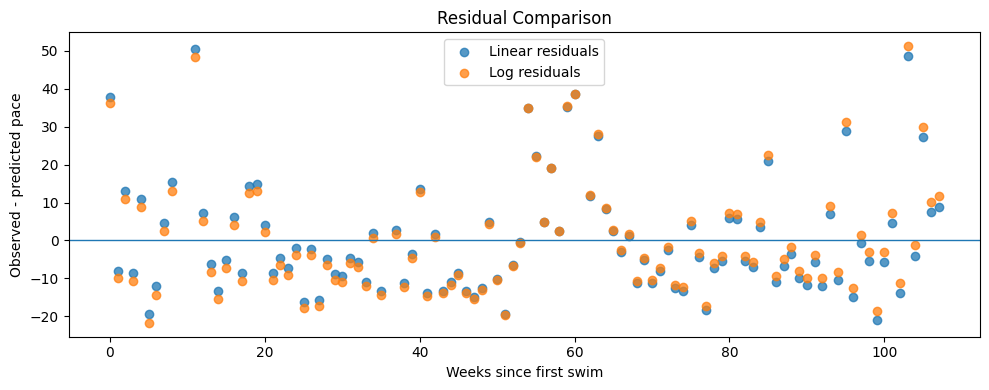

,linear_resid,log_resid
count,1.040000e+02,1.040000e+02
mean,8.745141e-15,4.919142e-15
std,1.479882e+01,1.492738e+01
min,-2.092727e+01,-2.170719e+01
25%,-1.044184e+01,-1.039219e+01
50%,-4.841078e+00,-4.002604e+00
75%,5.781901e+00,5.690439e+00
max,5.055768e+01,5.119875e+01


In [5]:
compare = model_df[["week_index", "avg_pace_sec_per_100m"]].copy()
compare["linear_pred"] = model_df["linear_pred"].values
compare["log_pred"] = log_df["log_pred"].values
compare["linear_resid"] = compare["avg_pace_sec_per_100m"] - compare["linear_pred"]
compare["log_resid"] = compare["avg_pace_sec_per_100m"] - compare["log_pred"]

plt.figure(figsize=(10, 4))
plt.axhline(0, linewidth=1)
plt.scatter(compare["week_index"], compare["linear_resid"], label="Linear residuals", alpha=.75)
plt.scatter(compare["week_index"], compare["log_resid"], label="Log residuals", alpha=.75)
plt.title("Residual Comparison")
plt.xlabel("Weeks since first swim")
plt.ylabel("Observed - predicted pace")
plt.legend()
plt.tight_layout()
plt.show()

compare[["linear_resid", "log_resid"]].describe()

## Training volume as a function

Weekly volume can also be modeled as a function of time:

$$
\widehat{\text{volume}} = m(\text{week}) + b
$$

A slope in meters per week answers: on average, how quickly did weekly training volume change?

Code-style implementation:

```python
vol_model = LinearRegression().fit(vol_df[["week_index"]], vol_df["total_distance_m"])
vol_df["volume_pred"] = vol_model.predict(vol_df[["week_index"]])
```

**Expected output:** Expect model fit information such as slopes, predictions, errors, or residuals. Focus on both the trend and how much variation remains unexplained.


Weekly volume model: volume = -24.6 * week + 15562.9
R²: 0.020


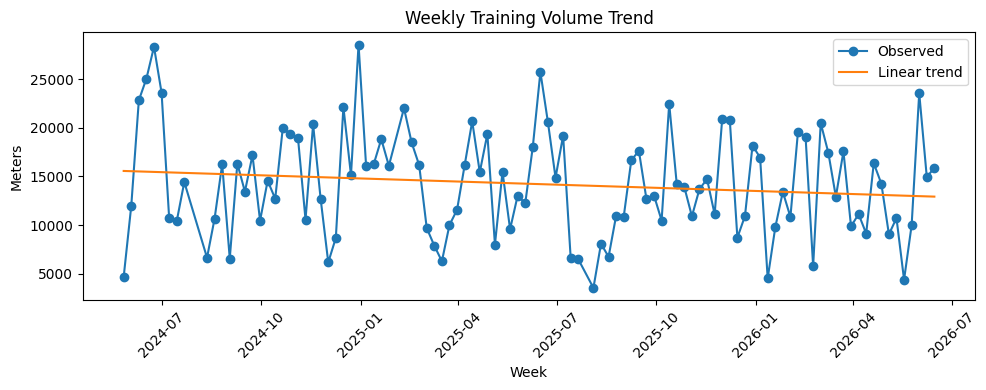

In [6]:
vol_df = weekly.dropna(subset=["week_index", "total_distance_m"]).copy()
vol_model = LinearRegression().fit(vol_df[["week_index"]], vol_df["total_distance_m"])
vol_df["volume_pred"] = vol_model.predict(vol_df[["week_index"]])

print(f"Weekly volume model: volume = {vol_model.coef_[0]:.1f} * week + {vol_model.intercept_:.1f}")
print(f"R²: {r2_score(vol_df['total_distance_m'], vol_df['volume_pred']):.3f}")

plt.figure(figsize=(10, 4))
plt.plot(vol_df["week_start"], vol_df["total_distance_m"], marker="o", label="Observed")
plt.plot(vol_df["week_start"], vol_df["volume_pred"], label="Linear trend")
plt.title("Weekly Training Volume Trend")
plt.xlabel("Week")
plt.ylabel("Meters")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()